# Why Random Weights? Symmetry Breaking & "Different Opinions, One Observation"

**The confusion this notebook untangles:** if a hidden layer has 4 neurons, and we say each neuron "learns something different," but they're all looking at the *exact same* observation (the same house) — how does that make sense? Aren't they supposed to be describing the same thing? And if they all learn different things, how do we ever get back down to *one* price?

We'll resolve this with the usual pattern: **hit a trap, feel why it fails, then fix it** — building everything from raw NumPy so nothing is hidden inside a framework.

**Roadmap**
1. **Trap** — initialize weights to zero, watch every neuron become an identical clone
2. **Fix** — random initialization breaks the symmetry
3. What "different things" really means (same observation, different *questions* about it)
4. How the output layer reconciles many hidden opinions into one number
5. Train for real — specialization becomes *meaningful*, not just different
6. Multiple outputs — same idea, just more aggregators reading the same specialists


## Part 0 — Setup: a small House Prices-style dataset

We use a synthetic dataset shaped like Kaggle House Prices (same 4 signature features:
`GrLivArea`, `OverallQual`, `YearBuilt`, `TotalBsmtSF`) so the numbers stay concrete.
Real feature meaning matters here — we want the hidden neurons' behavior to be
interpretable, not abstract.

We'll also pick **one single house** and keep coming back to it throughout the notebook.
Every trap, every fix, every visualization is about *that one house* — because the whole
point is: same observation, in, every time.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# --- Synthetic House Prices-style dataset ---
n_samples = 200
feature_names = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF']

GrLivArea    = np.random.normal(1500, 500, n_samples).clip(400, 4000)
OverallQual  = np.random.randint(1, 11, n_samples).astype(float)
YearBuilt    = np.random.normal(1975, 25, n_samples).clip(1900, 2024)
TotalBsmtSF  = np.random.normal(1000, 400, n_samples).clip(0, 3000)

SalePrice = (
    50 * GrLivArea
    + 15000 * OverallQual
    + 200 * (YearBuilt - 1900)
    + 40 * TotalBsmtSF
    + np.random.normal(0, 15000, n_samples)
).clip(30000, None)

df = pd.DataFrame({
    'GrLivArea': GrLivArea, 'OverallQual': OverallQual,
    'YearBuilt': YearBuilt, 'TotalBsmtSF': TotalBsmtSF, 'SalePrice': SalePrice
})

# Standardize features (mean 0, std 1) -- standard practice before feeding a NN
X_raw = df[feature_names].values
X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
X = (X_raw - X_mean) / X_std

y_raw = df['SalePrice'].values
y_mean, y_std = y_raw.mean(), y_raw.std()
y = (y_raw - y_mean) / y_std   # standardize target too, makes training stable

# Pick ONE house we will track through the entire notebook
house_idx = 7
x_house = X[house_idx]
raw_house = df.iloc[house_idx]

print("Our running example house (raw values):")
print(raw_house.to_string())
print("\nStandardized feature vector fed into the network:")
print(dict(zip(feature_names, np.round(x_house, 3))))


Our running example house (raw values):
GrLivArea        1883.717365
OverallQual         7.000000
YearBuilt        1971.323565
TotalBsmtSF      1018.959469
SalePrice      261297.922299

Standardized feature vector fed into the network:
{'GrLivArea': np.float64(0.873), 'OverallQual': np.float64(0.476), 'YearBuilt': np.float64(-0.096), 'TotalBsmtSF': np.float64(0.072)}


## Part 1 — THE TRAP: "Zero feels like a safe, neutral starting point"

If you've never hit this wall before, zero-initialization looks *reasonable*. Zero bias,
zero preference, let the data speak. Let's build a tiny network — 4 inputs → 4 hidden
neurons → 1 output — with every weight set to zero, and run our one house through it.


In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

n_in, n_hidden, n_out = 4, 4, 1

# --- ALL WEIGHTS ZERO ---
W1_zero = np.zeros((n_in, n_hidden))
b1_zero = np.zeros(n_hidden)
W2_zero = np.zeros((n_hidden, n_out))
b2_zero = np.zeros(n_out)

def forward(x, W1, b1, W2, b2):
    z1 = x @ W1 + b1
    h  = sigmoid(z1)
    z2 = h @ W2 + b2
    return z1, h, z2

z1, h, out = forward(x_house, W1_zero, b1_zero, W2_zero, b2_zero)

print("Hidden layer pre-activations (z1):", np.round(z1, 6))
print("Hidden layer activations   (h):  ", np.round(h, 6))
print("Final output:", np.round(out, 6))
print("\nNotice: all four hidden neurons produced the EXACT same number.")


Hidden layer pre-activations (z1): [0. 0. 0. 0.]
Hidden layer activations   (h):   [0.5 0.5 0.5 0.5]
Final output: [0.]

Notice: all four hidden neurons produced the EXACT same number.


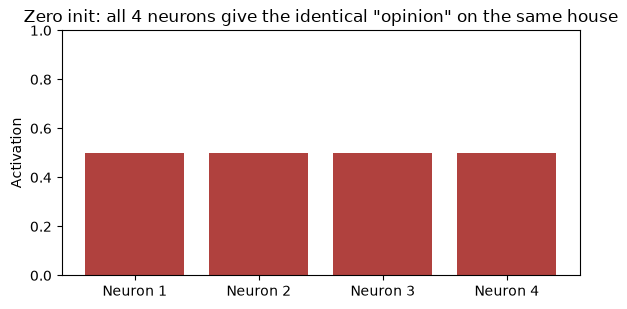

In [3]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar([f'Neuron {i+1}' for i in range(n_hidden)], h, color='#B0413E')
ax.set_ylabel('Activation')
ax.set_title('Zero init: all 4 neurons give the identical "opinion" on the same house')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


### Why this is a dead end, not just a slow start

It's tempting to think "fine, they're equal now, but training will spread them out."
It won't. Let's actually compute the gradient each hidden neuron receives during
backpropagation and check.


In [4]:
# Manual backprop for one house, MSE loss, target = standardized SalePrice
y_true = y[house_idx]

def backward(x, y_true, z1, h, out, W2):
    error = out - y_true                      # dL/d(out), shape (1,)
    dW2 = np.outer(h, error)                   # dL/dW2
    dh  = error @ W2.T                         # dL/dh, shape (n_hidden,)
    dz1 = dh * h * (1 - h)                     # sigmoid derivative
    dW1 = np.outer(x, dz1)                     # dL/dW1
    return dW1, dz1, dW2

dW1_zero, dz1_zero, dW2_zero = backward(x_house, y_true, z1, h, out, W2_zero)

print("Gradient arriving at each hidden neuron (dz1):", np.round(dz1_zero, 6))
print("\nEvery neuron gets the identical gradient too.")
print("Update W1 with this gradient and the four neurons move in lockstep --")
print("forever identical, no matter how many epochs you train.")


Gradient arriving at each hidden neuron (dz1): [0. 0. 0. 0.]

Every neuron gets the identical gradient too.
Update W1 with this gradient and the four neurons move in lockstep --
forever identical, no matter how many epochs you train.


**The trap, stated plainly:** with zero (or any *identical*) initialization, every
neuron in a layer computes the same thing, gets the same error signal, and updates the
same way. A 4-neuron hidden layer behaves exactly like a 1-neuron hidden layer wearing a
costume. Width becomes useless. This is the **symmetry problem**, and no amount of
training escapes it — the starting point itself is broken.


## Part 2 — THE FIX: random initialization breaks the symmetry

The fix isn't really "add randomness" for its own sake — it's "make sure no two neurons
start out computing the same function." Random numbers are just the cheapest, most
reliable way to guarantee that. Let's re-run the *same house* through a *freshly*
randomly-initialized network.


In [5]:
# Small random weights (we'll justify the scale properly in Part 5 with variance math)
W1 = np.random.randn(n_in, n_hidden) * 0.5
b1 = np.zeros(n_hidden)
W2 = np.random.randn(n_hidden, n_out) * 0.5
b2 = np.zeros(n_out)

z1, h, out = forward(x_house, W1, b1, W2, b2)

print("Hidden activations for the SAME house, random init:", np.round(h, 4))
print("These are four different numbers -- for one, unchanged, single observation.")


Hidden activations for the SAME house, random init: [0.5847 0.3649 0.4685 0.6738]
These are four different numbers -- for one, unchanged, single observation.


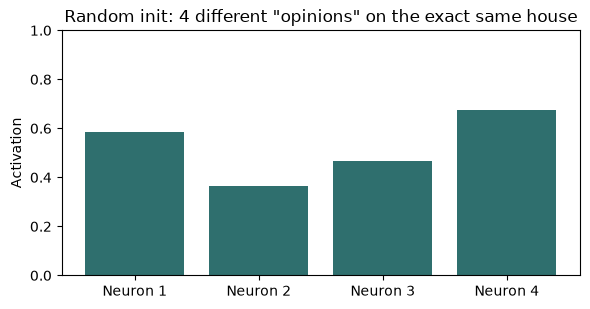

In [6]:
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar([f'Neuron {i+1}' for i in range(n_hidden)], h, color='#2F6F6E')
ax.set_ylabel('Activation')
ax.set_title('Random init: 4 different "opinions" on the exact same house')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


This is the moment worth sitting with: **the input didn't change. Only the weights
did.** Four neurons, four different weight vectors, four different ways of combining the
same 4 numbers (`GrLivArea`, `OverallQual`, `YearBuilt`, `TotalBsmtSF`) — so naturally,
four different results. That's not four different observations. It's four different
*lenses* pointed at one observation.


## Part 3 — What does "learning different things" actually mean?

Each hidden neuron's weight vector is literally a set of preferences over the *same 4
input features*. Neuron 1 might weight `OverallQual` heavily and ignore `YearBuilt`.
Neuron 2 might do the opposite. Neither neuron ever sees a different house — they just
ask a different **question** about the house.

A useful analogy: think of the 4 hidden neurons as 4 junior appraisers looking at the
same listing. One focuses on square footage, one on build quality, one on age, one on
basement space. They don't disagree about what house they're looking at — they emphasize
different *aspects* of it.


Each column = one neuron's 'preferences' over the same 4 features:

             Neuron 1  Neuron 2  Neuron 3  Neuron 4
GrLivArea       0.783    -0.033    -0.278     0.941
OverallQual    -0.724    -1.099     0.220    -0.251
YearBuilt      -0.511     0.354     0.122    -0.282
TotalBsmtSF    -0.640     0.436     0.325    -0.050


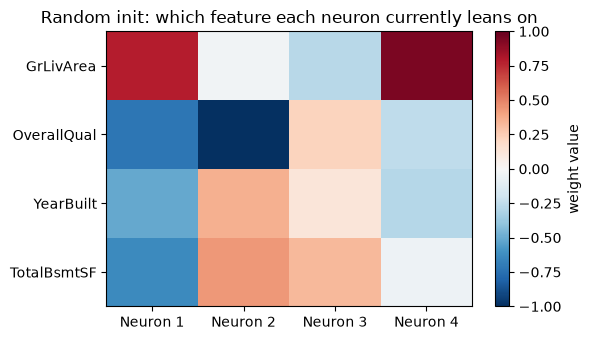

In [7]:
weight_df = pd.DataFrame(W1, index=feature_names,
                          columns=[f'Neuron {i+1}' for i in range(n_hidden)])
print("Each column = one neuron's 'preferences' over the same 4 features:\n")
print(weight_df.round(3))

fig, ax = plt.subplots(figsize=(6, 3.5))
im = ax.imshow(W1, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(n_hidden)); ax.set_xticklabels([f'Neuron {i+1}' for i in range(n_hidden)])
ax.set_yticks(range(n_in)); ax.set_yticklabels(feature_names)
ax.set_title('Random init: which feature each neuron currently leans on')
plt.colorbar(im, ax=ax, label='weight value')
plt.tight_layout()
plt.show()


Right now these weights are just random noise — no neuron has *learned* to specialize
in anything yet, they're only *capable* of specializing because they started distinct.
Part 5 is where training turns "different" into "meaningfully different."


## Part 4 — Reconciling 4 opinions into 1 price

So we have 4 different hidden activations for one house. How does that collapse back
down to a single `SalePrice` prediction? The output layer is just another weighted
combination — this time combining the 4 *opinions* instead of the 4 *raw features*.


In [8]:
contributions = h * W2.flatten()   # each neuron's weighted contribution to the output
total = contributions.sum() + b2[0]

contrib_df = pd.DataFrame({
    'Neuron activation (h)': np.round(h, 4),
    'Output weight (W2)':    np.round(W2.flatten(), 4),
    'Contribution to output': np.round(contributions, 4)
}, index=[f'Neuron {i+1}' for i in range(n_hidden)])
print(contrib_df)
print(f"\nSum of contributions + bias = {total:.4f}  (matches network output: {out[0]:.4f})")


          Neuron activation (h)  Output weight (W2)  Contribution to output
Neuron 1                 0.5847              0.9233                  0.5398
Neuron 2                 0.3649             -0.5350                 -0.1952
Neuron 3                 0.4685             -0.7628                 -0.3574
Neuron 4                 0.6738             -0.3460                 -0.2331

Sum of contributions + bias = -0.2459  (matches network output: -0.2459)


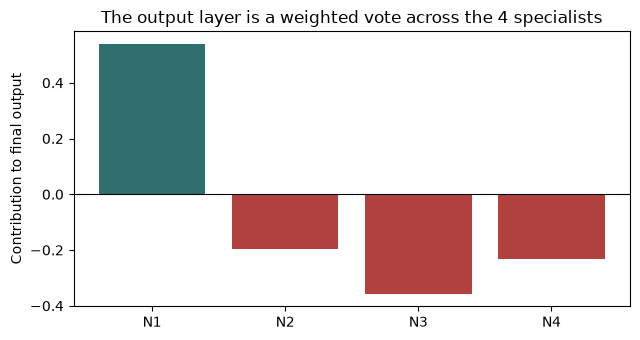

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
colors = ['#2F6F6E' if c >= 0 else '#B0413E' for c in contributions]
ax.bar([f'N{i+1}' for i in range(n_hidden)], contributions, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Contribution to final output')
ax.set_title('The output layer is a weighted vote across the 4 specialists')
plt.tight_layout()
plt.show()


**The key sentence to give students:** *the hidden layer doesn't learn 4 different
observations — it learns 4 different lenses on the same observation, and the output
layer decides how much to trust each lens.* Diversity in the hidden layer isn't a
contradiction of "one output" — it's the *raw material* the output layer needs in order
to make a good single decision. A committee of 4 identical clones (the zero-init trap)
gives the output layer nothing extra to work with; a committee of 4 different specialists
gives it real signal to combine.


## Part 5 — Training: from "different" to "meaningfully different"

Random init only guarantees the neurons *start* different. Training is what makes their
differences *useful* — each neuron's weights adjust to reduce the error, and because
they started from different points, gradient descent pulls them toward different,
complementary roles. Let's train the full network on all 200 houses and watch it happen.


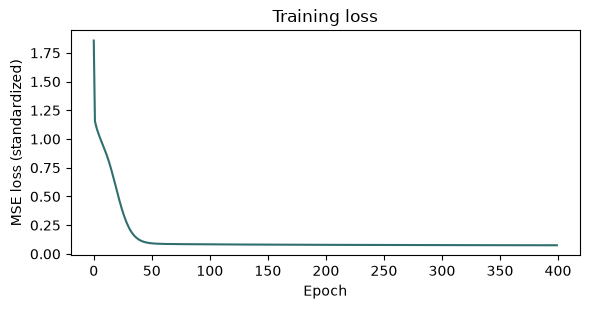

In [10]:
def train(X, y, n_hidden=4, epochs=400, lr=0.5, seed=42):
    rng = np.random.RandomState(seed)
    n_in = X.shape[1]
    W1 = rng.randn(n_in, n_hidden) * 0.5
    b1 = np.zeros(n_hidden)
    W2 = rng.randn(n_hidden, 1) * 0.5
    b2 = np.zeros(1)

    history = {'loss': [], 'W1': [], 'house_h': []}

    for epoch in range(epochs):
        z1 = X @ W1 + b1
        h = sigmoid(z1)
        out = h @ W2 + b2
        error = out.flatten() - y
        loss = np.mean(error ** 2)

        dW2 = h.T @ error.reshape(-1, 1) / len(X)
        dh = np.outer(error, W2.flatten())
        dz1 = dh * h * (1 - h)
        dW1 = X.T @ dz1 / len(X)
        db2 = error.mean()
        db1 = dz1.mean(axis=0)

        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2

        history['loss'].append(loss)
        if epoch % 20 == 0:
            history['W1'].append(W1.copy())
            _, h_house, _ = forward(x_house, W1, b1, W2, b2)
            history['house_h'].append(h_house.copy())

    return W1, b1, W2, b2, history

W1_t, b1_t, W2_t, b2_t, hist = train(X, y)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(hist['loss'], color='#2F6F6E')
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE loss (standardized)')
ax.set_title('Training loss')
plt.tight_layout()
plt.show()


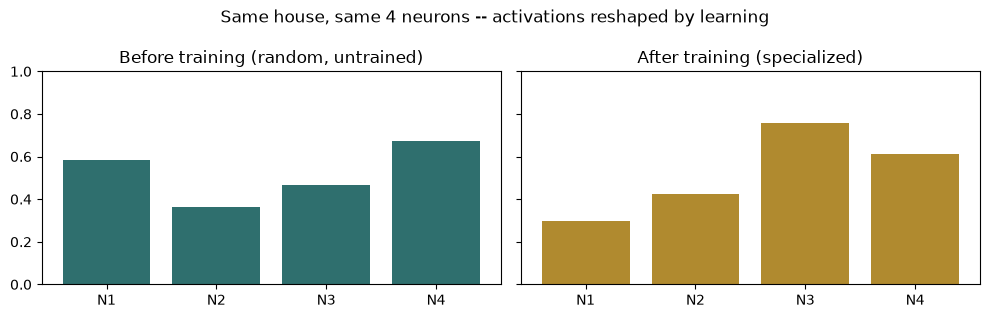

Predicted SalePrice for our house: $263,575
Actual SalePrice:                  $261,298


In [11]:
# Our one house's 4 hidden activations, before vs after training
_, h_before, _ = forward(x_house, W1, b1, W2, b2)   # random-init network from Part 2
_, h_after, out_after = forward(x_house, W1_t, b1_t, W2_t, b2_t)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=True)
axes[0].bar([f'N{i+1}' for i in range(n_hidden)], h_before, color='#2F6F6E')
axes[0].set_title('Before training (random, untrained)')
axes[1].bar([f'N{i+1}' for i in range(n_hidden)], h_after, color='#B08A2F')
axes[1].set_title('After training (specialized)')
for a in axes: a.set_ylim(0, 1)
plt.suptitle('Same house, same 4 neurons -- activations reshaped by learning')
plt.tight_layout()
plt.show()

pred_price = out_after[0] * y_std + y_mean
print(f"Predicted SalePrice for our house: ${pred_price:,.0f}")
print(f"Actual SalePrice:                  ${raw_house['SalePrice']:,.0f}")


Correlation between each neuron's activation and each raw feature,
measured across all 200 houses:

          GrLivArea  OverallQual  YearBuilt  TotalBsmtSF
Neuron 1      -0.36        -0.75      -0.28        -0.36
Neuron 2      -0.13        -0.13      -0.01        -0.95
Neuron 3       0.32         0.88       0.11        -0.21
Neuron 4       0.73        -0.09      -0.46        -0.58


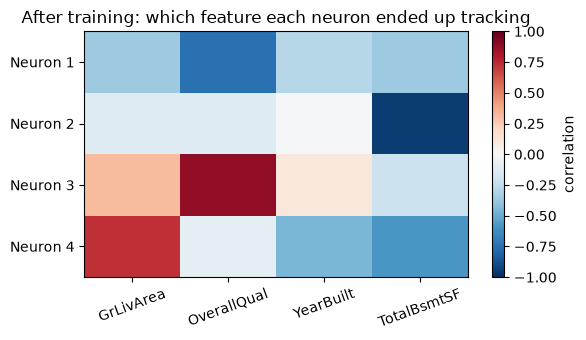

In [12]:
# Does each neuron correlate with a particular feature across ALL houses?
# (a rough, illustrative check of emergent specialization -- not guaranteed exact)
z1_all = X @ W1_t + b1_t
h_all = sigmoid(z1_all)

corr = np.zeros((n_hidden, n_in))
for i in range(n_hidden):
    for j in range(n_in):
        corr[i, j] = np.corrcoef(h_all[:, i], X[:, j])[0, 1]

corr_df = pd.DataFrame(corr, index=[f'Neuron {i+1}' for i in range(n_hidden)],
                        columns=feature_names)
print("Correlation between each neuron's activation and each raw feature,")
print("measured across all 200 houses:\n")
print(corr_df.round(2))

fig, ax = plt.subplots(figsize=(6, 3.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(n_in)); ax.set_xticklabels(feature_names, rotation=20)
ax.set_yticks(range(n_hidden)); ax.set_yticklabels([f'Neuron {i+1}' for i in range(n_hidden)])
ax.set_title('After training: which feature each neuron ended up tracking')
plt.colorbar(im, ax=ax, label='correlation')
plt.tight_layout()
plt.show()


If you look at the heatmap above, you'll typically see each neuron leaning more
strongly toward one or two features than the others -- that's specialization *emerging*
from training, not something we told the network to do. It's a direct, visible
consequence of the neurons having started at different random points in Part 2.

**This is the full arc:** zero init → forced identical clones → useless width. Random
init → different starting lenses → training sharpens each lens into a genuine
specialist → the output layer combines the specialists into one accurate number.


## Part 6 — Multiple outputs: the same idea, just more aggregators

What if we wanted to predict *two* things from the same house -- say `SalePrice` and a
made-up `DaysOnMarket` score? Nothing changes about the hidden layer. We just add a
second output neuron that reads from the **same 4 specialists**, but with its own set of
trust weights.


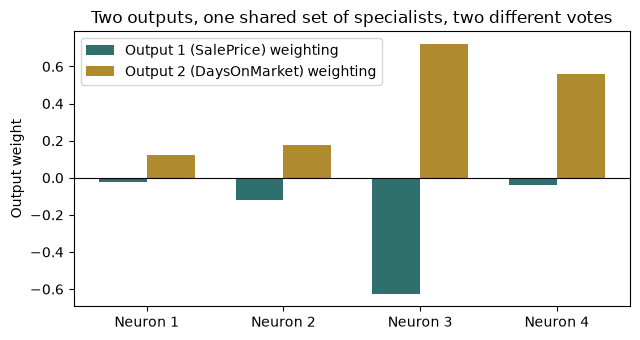

In [13]:
n_out2 = 2
W2_multi = np.random.randn(n_hidden, n_out2) * 0.5
b2_multi = np.zeros(n_out2)

_, h_house2, out_multi = forward(x_house, W1_t, b1_t, W2_multi, b2_multi)

fig, ax = plt.subplots(figsize=(6.5, 3.5))
width = 0.35
xpos = np.arange(n_hidden)
ax.bar(xpos - width/2, W2_multi[:, 0], width, label='Output 1 (SalePrice) weighting', color='#2F6F6E')
ax.bar(xpos + width/2, W2_multi[:, 1], width, label='Output 2 (DaysOnMarket) weighting', color='#B08A2F')
ax.set_xticks(xpos); ax.set_xticklabels([f'Neuron {i+1}' for i in range(n_hidden)])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Output weight')
ax.set_title('Two outputs, one shared set of specialists, two different votes')
ax.legend()
plt.tight_layout()
plt.show()


Same 4 hidden activations feed **both** outputs -- the network isn't duplicating
its understanding of the house, it's re-using it. Output 1 might trust Neuron 2
(quality-focused) heavily for price; Output 2 might trust Neuron 3 (age-focused) more
for predicting how long a house sits on the market. This is exactly how real
multi-output networks (and, at a larger scale, multi-task networks) share a learned
representation while producing distinct predictions.


## Recap for students

- **Trap:** identical (e.g. zero) initial weights → identical neurons → identical
  gradients → a wide layer that behaves like a single neuron forever.
- **Fix:** random initialization guarantees neurons start out *different*, which is a
  prerequisite for them ever becoming *usefully* different.
- **The confusion, resolved:** "learning different things for the same observation"
  means each neuron applies a different *weighting* to the same input features --
  not that the neurons are looking at different houses. They're different **questions**,
  not different **data**.
- **Reconciliation:** the output layer is just another weighted combination -- it takes
  several different opinions about one house and turns them into one number, the same
  way a manager combines several analysts' opinions into one decision.
- **Training** is what turns "randomly different" into "meaningfully different" --
  neurons drift toward specializing in whichever features most reduce the error.
- **Multiple outputs** don't need multiple hidden layers -- they just need multiple
  aggregators reading from the same shared specialists.

### Reflection questions
1. If you initialized all 4 neurons to the *same* random value (not zero, but all equal
   to, say, 0.3), would the symmetry problem still happen? Why?
2. In Part 4, what would happen to the final prediction if `W2` for one neuron were
   exactly 0? What does that mean in plain English about how much the output layer
   "trusts" that neuron?
3. Looking at the correlation heatmap in Part 5 -- if two neurons ended up with almost
   identical correlation patterns, what would that tell you about whether your hidden
   layer is "wide enough"?
